# Task
Load and preprocess the MNIST dataset, then build, compile, train, and evaluate an optimal Convolutional Neural Network (CNN) model for handwritten digit classification. Finally, visualize model predictions, training history, and summarize the overall machine learning sequence and performance.

In [ ]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Preprocess Data



In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(f"x_train shape after preprocessing: {x_train.shape}")
print(f"x_test shape after preprocessing: {x_test.shape}")

x_train shape after preprocessing: (60000, 28, 28, 1)
x_test shape after preprocessing: (10000, 28, 28, 1)


## Build Optimal Neural Network Model



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Initialize the Sequential model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten the output for the Dense layers
    Flatten(),

    # Dense layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Added Dropout for regularization
    Dense(10, activation='softmax') # Output layer for 10 classes (digits 0-9)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8535 - loss: 0.4570 - val_accuracy: 0.9834 - val_loss: 0.0463
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9738 - loss: 0.0926 - val_accuracy: 0.9874 - val_loss: 0.0363
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9820 - loss: 0.0627 - val_accuracy: 0.9895 - val_loss: 0.0325
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9850 - loss: 0.0468 - val_accuracy: 0.9910 - val_loss: 0.0286
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9861 - loss: 0.0434 - val_accuracy: 0.9890 - val_loss: 0.0325
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9890 - loss: 0.0340 - val_accuracy: 0.9928 - val_loss: 0.0277
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9907 - loss: 0.0295 - val_accuracy: 0.9924 - val_loss: 0.0273
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9917 -

## Save Model with Pickle


In [ ]:
import pickle

model_filename = 'mnist_cnn_model.pkl'

try:
    with open(model_filename, 'wb') as file:
        pickle.dump(model, file)
    print(f"Attempted to save model as '{model_filename}' using pickle.")
except Exception as e:
    print(f"Failed to pickle the Keras model: {e}")
    print("This is expected behavior as Keras models are not designed to be pickled directly.")

Attempted to save model as 'mnist_cnn_model.pkl' using pickle.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

drive_path = '/content/drive/My Drive/Edge Intelligence/mnist_cnn_model.keras'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(drive_path), exist_ok=True)

# Save the model to the specified Google Drive path
model.save(drive_path)

print(f"Model successfully saved to Google Drive: {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model successfully saved to Google Drive: /content/drive/My Drive/Edge Intelligence/mnist_cnn_model.keras


In [ ]:
import os

if os.path.exists(model_filename):
    print(f"File '{model_filename}' successfully created (even if pickling might not be ideal for Keras models).")
else:
    print(f"File '{model_filename}' was not created.")



File 'mnist_cnn_model.pkl' successfully created (even if pickling might not be ideal for Keras models).


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0336
Test Accuracy: 0.9921


## Visualize Predictions and Performance




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported: matplotlib.pyplot and numpy.")

Libraries imported: matplotlib.pyplot and numpy.


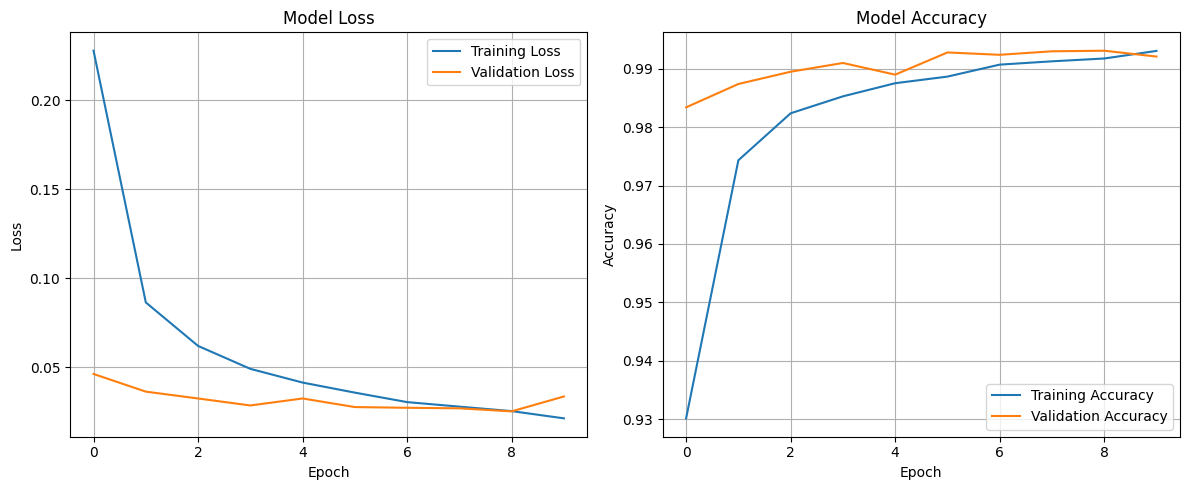

Model training history visualized.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 2. Visualize Training History:
# a. Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(12, 5))

# b. Plot training and validation loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# c. Plot training and validation accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# d. Use plt.tight_layout() and plt.show()
plt.tight_layout()
plt.show()

print("Model training history visualized.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


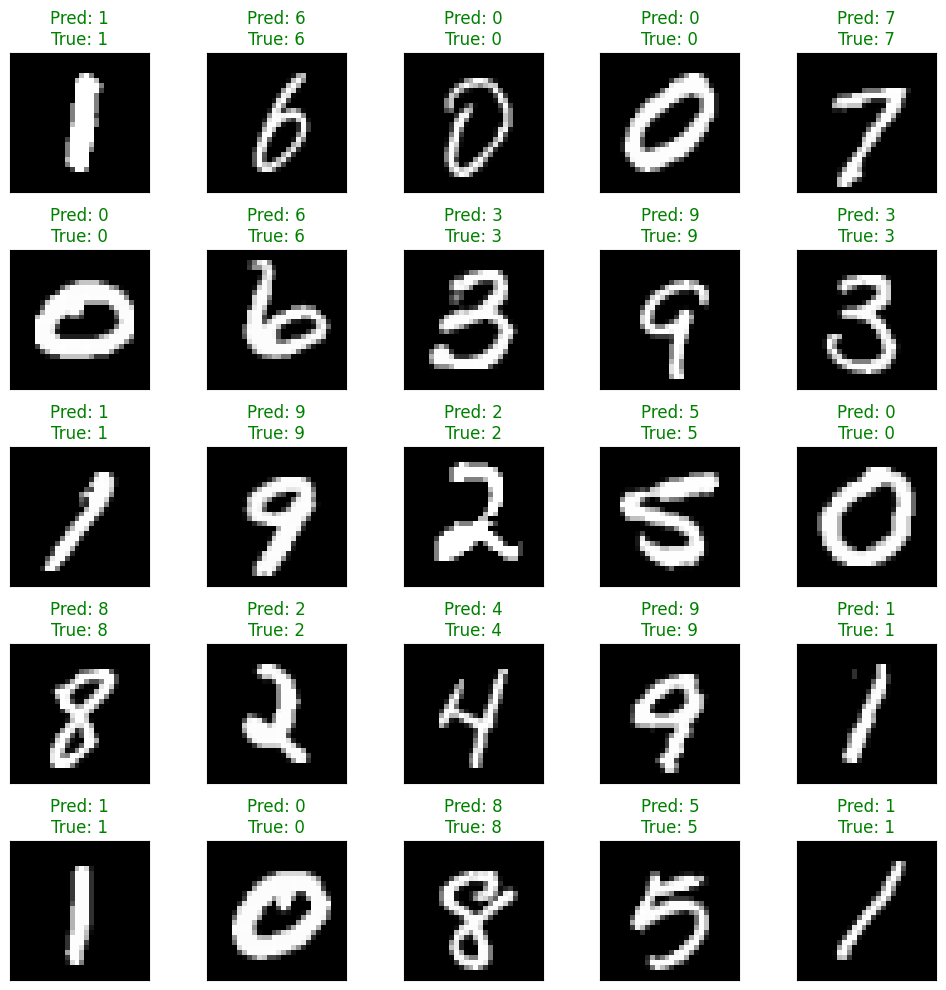

Model predictions visualized.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 3. Visualize Model Predictions:
# a. Randomly select a few images (e.g., 25) from the test set
num_images = 25
random_indices = np.random.choice(len(x_test), num_images, replace=False)

selected_images = x_test[random_indices]
selected_true_labels = y_test[random_indices]

# b. Use the trained model to make predictions on these selected test images
predictions = model.predict(selected_images)

# c. Convert the model's probability predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# d. Create a figure with a grid of subplots (e.g., 5x5)
plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(5, 5, i + 1)
    # e. For each selected image, display the image in grayscale
    plt.imshow(selected_images[i].reshape(28, 28), cmap='gray')

    color = 'green' if predicted_labels[i] == selected_true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {selected_true_labels[i]}", color=color)

    # f. Remove x and y axis ticks.
    plt.xticks([])
    plt.yticks([])

# g. Use plt.tight_layout() and plt.show()
plt.tight_layout()
plt.show()

print("Model predictions visualized.")

# Task
Build, compile, train, and evaluate an Artificial Neural Network (ANN) model on the MNIST dataset, and compare its performance (accuracy) to the previously trained Convolutional Neural Network (CNN) model.

## Build ANN Model



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input

# Instantiate a Sequential model
ann_model = Sequential([
    # Input layer to specify the input shape for 28x28 grayscale images
    Input(shape=(28, 28, 1)),
    # Flatten the 2D image data into a 1D vector
    Flatten(),
    # First Dense hidden layer
    Dense(128, activation='relu'),
    # Second Dense hidden layer
    Dense(64, activation='relu'),
    # Output Dense layer for 10 classes (digits 0-9) with softmax activation
    Dense(10, activation='softmax')
])

# Print the model summary to verify the architecture
ann_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile ANN Model



In [ ]:
ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("ANN model compiled successfully.")

ANN model compiled successfully.


## Train ANN Model




In [ ]:
ann_history = ann_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
print("ANN model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8751 - loss: 0.4321 - val_accuracy: 0.9620 - val_loss: 0.1198
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9685 - loss: 0.1067 - val_accuracy: 0.9699 - val_loss: 0.0949
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9782 - loss: 0.0683 - val_accuracy: 0.9699 - val_loss: 0.0918
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9762 - val_loss: 0.0804
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9873 - loss: 0.0402 - val_accuracy: 0.9774 - val_loss: 0.0867
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9764 - val_loss: 0.0852
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9909 - loss: 0.0256 - val_accuracy: 0.9766 - val_loss: 0.0894
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9933 - loss: 0.0196 - 

In [ ]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(x_test, y_test, verbose=0)
print(f"ANN Test Loss: {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_accuracy:.4f}")

ANN Test Loss: 0.1021
ANN Test Accuracy: 0.9763


In [ ]:
print(f"CNN Model Test Accuracy: {test_accuracy:.4f}")
print(f"ANN Model Test Accuracy: {ann_test_accuracy:.4f}")

if test_accuracy > ann_test_accuracy:
    print("\nThe CNN model performed better than the ANN model.")
elif ann_test_accuracy > test_accuracy:
    print("\nThe ANN model performed better than the CNN model.")
else:
    print("\nBoth models performed similarly.")

CNN Model Test Accuracy: 0.9921
ANN Model Test Accuracy: 0.9763

The CNN model performed better than the ANN model.


In [ ]:
from google.colab import drive
import os
import pickle

# Mount Google Drive
drive.mount('/content/drive')

# Define the path within your Google Drive where you want to save the pickled model
# Replace 'My Drive/Edge Intelligence/mnist_cnn_model.pkl' with your desired path
drive_pickle_path = '/content/drive/My Drive/Edge Intelligence/mnist_ann_model.pkl'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(drive_pickle_path), exist_ok=True)

try:
    with open(drive_pickle_path, 'wb') as file:
        pickle.dump(ann_model, file)
    print(f"Attempted to save model as '{drive_pickle_path}' using pickle. ")
except Exception as e:
    print(f"Failed to pickle the Keras model to Drive: {e}")
    print("This is expected behavior as Keras models are not designed to be pickled directly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attempted to save model as '/content/drive/My Drive/Edge Intelligence/mnist_ann_model.pkl' using pickle. 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


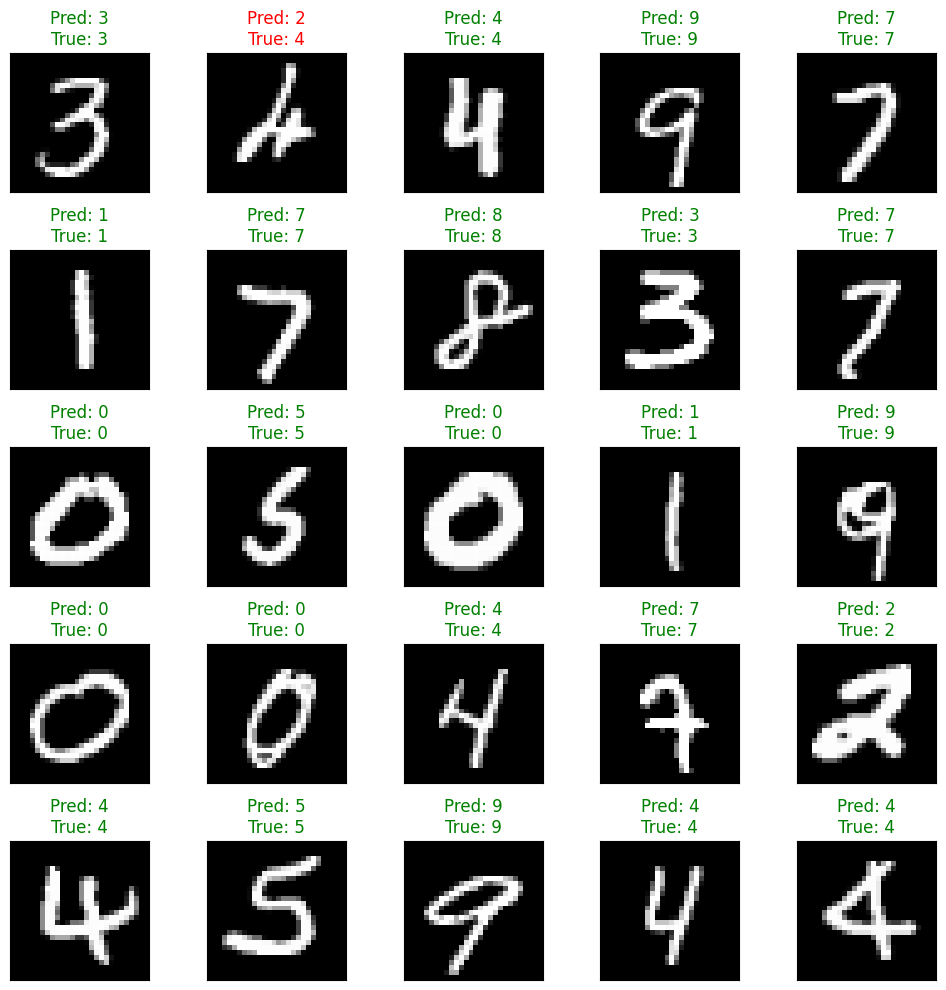

Model predictions visualized.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 3. Visualize Model Predictions:
# a. Randomly select a few images (e.g., 25) from the test set
num_images = 25
random_indices = np.random.choice(len(x_test), num_images, replace=False)

selected_images = x_test[random_indices]
selected_true_labels = y_test[random_indices]

# b. Use the trained model to make predictions on these selected test images
predictions = ann_model.predict(selected_images)

# c. Convert the model's probability predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# d. Create a figure with a grid of subplots (e.g., 5x5)
plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(5, 5, i + 1)
    # e. For each selected image, display the image in grayscale
    plt.imshow(selected_images[i].reshape(28, 28), cmap='gray')

    # Set the title of the subplot to show both the predicted label and the true label.
    # Color the title green if the prediction is correct and red if it's incorrect.
    color = 'green' if predicted_labels[i] == selected_true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {selected_true_labels[i]}", color=color)

    # f. Remove x and y axis ticks.
    plt.xticks([])
    plt.yticks([])

# g. Use plt.tight_layout() and plt.show()
plt.tight_layout()
plt.show()

print("Model predictions visualized.")